In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
m = 5000
mu = np.array([0 ,0])
sigma = np.array([[3, 1.5],
                  [1.5, 1]])

X = np.random.multivariate_normal(mu, sigma, m)
X = np.asmatrix(X)
print(X)

[[-4.15486398 -2.16299417]
 [ 0.33440265 -0.1528618 ]
 [-0.62666949 -0.34482423]
 ...
 [ 1.23615855 -0.29214578]
 [ 1.57135628  0.55769868]
 [ 1.07974     0.88213143]]


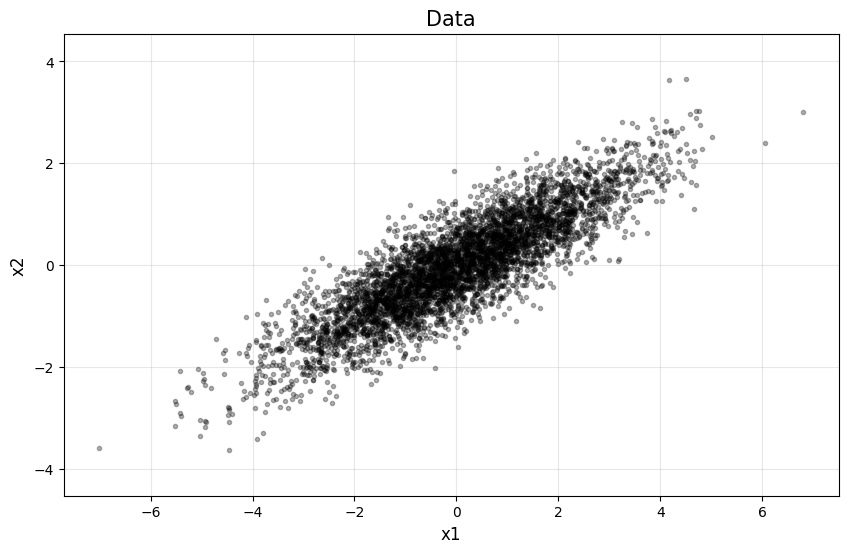

In [ ]:
plt.figure(figsize=(10, 6))

# clear visibility for overlapping dots (alpha = 0.3)
plt.plot(X[:, 0], X[:, 1], 'k.', alpha=0.3)

plt.title('Data', fontsize=15)
plt.xlabel('x1', fontsize=12)
plt.ylabel('x2', fontsize=12)
plt.grid(alpha=0.3)

plt.axis('equal')

plt.show()

In [ ]:
# Covariance Matrix
S = 1/(m-1)*X.T*X
S = np.asmatrix(S)

# Eigenvalue D, Eigenvector U
D, U = np.linalg.eig(S)

print(D,'\n')
print(U)

[3.75291239 0.19876239] 

[[ 0.88055209 -0.47394939]
 [ 0.47394939  0.88055209]]


In [ ]:
# Sort in descending order
idx = np.argsort(-D)
D = D[idx]
U = U[:, idx]

print(D,'\n')
print(U)

[3.75291239 0.19876239] 

[[ 0.88055209 -0.47394939]
 [ 0.47394939  0.88055209]]


In [ ]:
# 제1주성분(PC1)의 기울기 계산 (dy/dx)
h = U[1,0]/U[0,0]
xp = np.arange(-6, 6, 0.1)
yp = h*xp

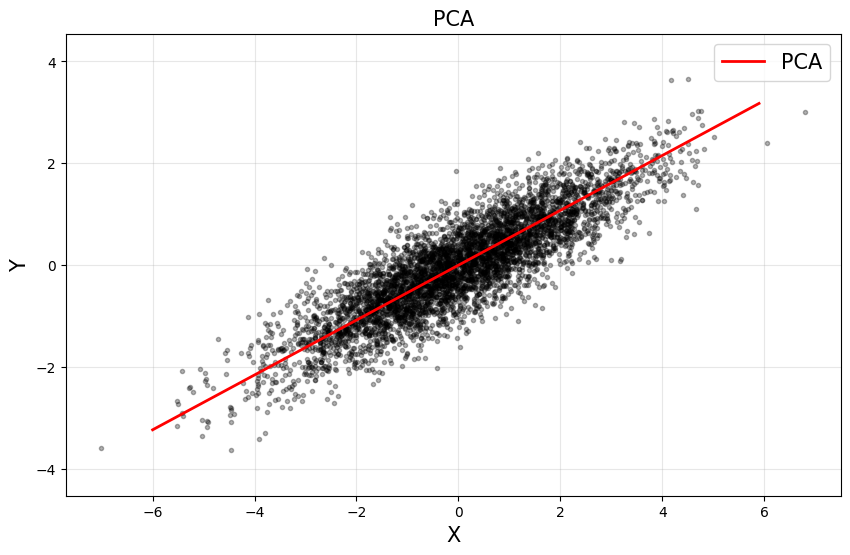

In [ ]:
plt.figure(figsize=(10,6))
plt.title("PCA", fontsize=15)
plt.xlabel("X", fontsize=15)
plt.ylabel("Y", fontsize=15)
plt.plot(X[:, 0], X[:, 1], 'k.', alpha=0.3)

# straight line
plt.plot(xp, yp, "r", linewidth=2, label="PCA")
plt.legend(fontsize=15)
plt.axis("equal")
plt.grid(alpha=0.3)
plt.show()

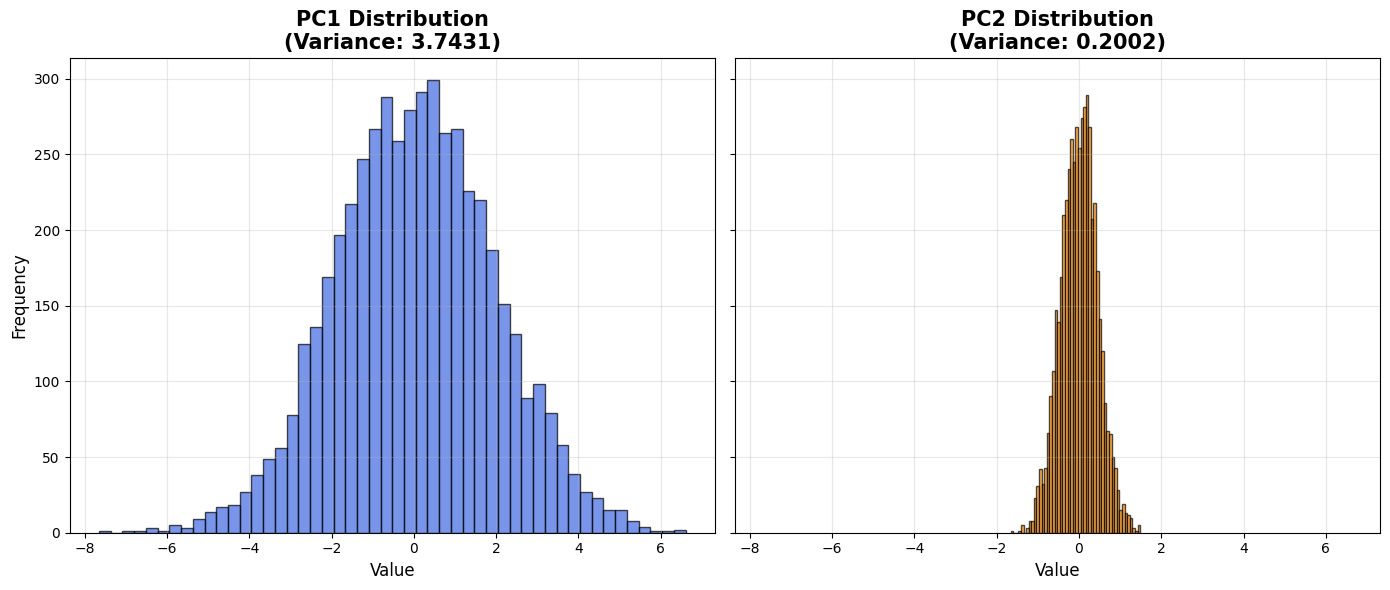

In [ ]:
# Z[:, 0] = PC1, Z[:, 1] = PC2
Z = X * U

# sharex=True, sharey=True: 두 그래프의 축 범위를 통일하여 '크기 차이'를 보여준다
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# PC1 Distribution
axes[0].hist(np.array(Z[:, 0]), bins=50, color='royalblue', alpha=0.7, edgecolor='black')
axes[0].set_title(f"PC1 Distribution\n(Variance: {D[0]:.4f})", fontsize=15, fontweight='bold')
axes[0].set_xlabel("Value", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)
axes[0].grid(alpha=0.3)

# PC2 Distribution
axes[1].hist(np.array(Z[:, 1]), bins=50, color='darkorange', alpha=0.7, edgecolor='black')
axes[1].set_title(f"PC2 Distribution\n(Variance: {D[1]:.4f})", fontsize=15, fontweight='bold')
axes[1].set_xlabel("Value", fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Using Skit-Learn**

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X = np.asarray(X)
pca.fit(X)

PCA(n_components=2)

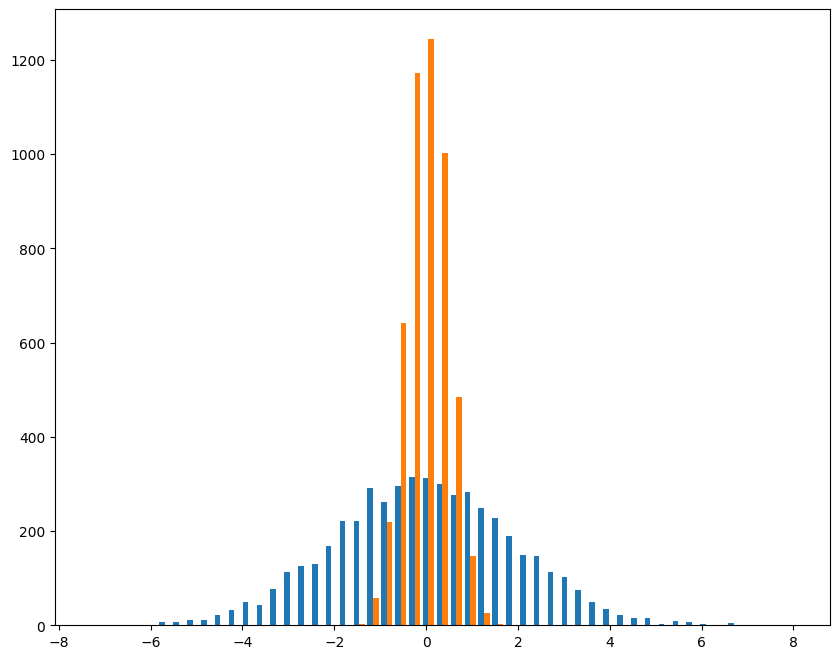

In [ ]:
u = pca.transform(X)

plt.figure(figsize = (10, 8))
plt.hist(u, 51)
plt.show()